# Questão 2
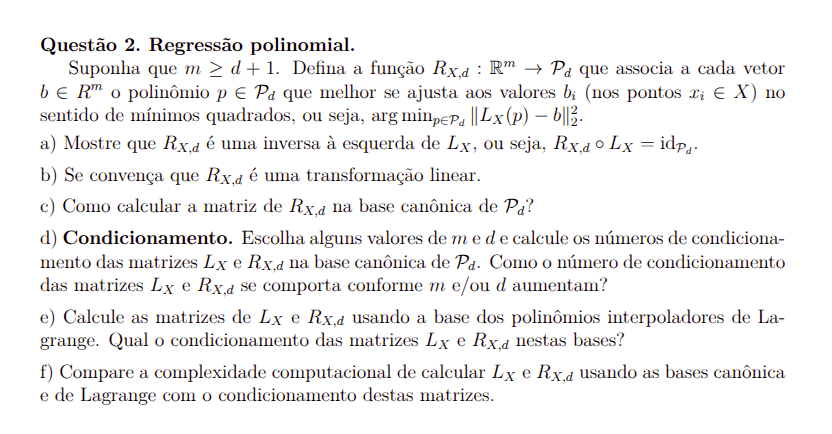

## Item a)

Para provarmos que a função $R_{X, d}$ é uma inversa à esquerda de $L_X$, vamos provar que a aplicação sucessiva dessas duas transformações a um polinômio $p$ retorna sempre o próprio $p$, ou seja, $R_{X, d}(L_X(p))=p$ $\forall p \in \mathcal{P}_d$


Seja $q$ um polinômio em $\mathcal{P}_d$. A transformação $L_X(q)$ nos retorna um vetor $b \in \mathbb{R}^m$ tal que $b_i = q(x_i)$. 

$L_X(q) = b \implies ||L_X(p) - b||_2^2 = ||L_X(p) - L_X(q)||_2^2$

Como visto na questão 1, $L_X$ é linear e, então, $||L_X(p) - L_X(q)||_2^2 = ||L_X(p-q)||_2^2$

Sabemos que a norma é uma função não negativa, portanto $||L_X(p-q)||_2^2 \geq 0$, $ \forall p \in \mathcal{P}_d$.

Mas se $p=q$, temos $||L_X(p-q)||_2^2 = ||L_X(0)||_2^2 = ||0||_2^2 = 0$. 

Assim, $||L_X(q) - b||_2^2 \leq ||L_X(p) - b||_2^2$ $\forall p \in \mathcal{P}_d$

Como $m \geq d+1$, $L_X$ é "magra e alta" e, conforme questão anterior, tem posto cheio nas colunas. Portanto, o problema de mínimos quadrados tem solução única.

Desse modo, $q = arg min_{p \in P_d} ||L_X(p) - b||_2^2 = R_{X, d}(L_X(q))$

## Item b)

Nessa resolução, precisávamos de uma operação que fosse linear, diferente da norma! No caso, conseguimos desenvolver uma demonstração para $R_{X, d}(\alpha a) = R_{X, d}(a)$ usando diretamente o quadrado da norma, mas não conseguíamos usar a mesma estratégia para soma. Daí pensamos no produto interno!

Seja $R_{X, d}(a) = q_a, R_{X, d}(b)=q_b$

$q_a = argmin_{p \in \mathcal{P}_d}||L_X(p) - a||_2^2$ e sabemos, do curso de Álgebra linear, que $p$ é solução única de um problema de mínimos quadrados se e somente se a diferença entre $L_X(p)$ e $a$ é ortogonal ao espaço coluna de $L_X$. 

Temos, então, $ \langle L_X(q_a) - a, L_X(p) \rangle = 0$, $\forall p \in \mathcal{P}_d$. Analogamente, $ \langle L_X(q_b) - b, L_X(p) \rangle = 0$, $\forall p \in \mathcal{P}_d$

Multiplicando a segunda equação por um escalar $\alpha$ e somando, temos:

 $ \langle L_X(q_a) - a, L_X(p) \rangle + \alpha \langle L_X(q_b) - b, L_X(p) \rangle = 0$, $\forall p \in \mathcal{P}_d$  
 
 Pela linearidade do produto interno:

 $\langle L_X(q_a + \alpha q_b) - \alpha b - a, L_X(p) \rangle = 0$, $\forall p \in \mathcal{P}_d$

Mas então $q_a + \alpha q_b$ é solução para o problema de mínimos quadrados $argmin_{p \in \mathcal{P}_d}||L_X(p) - (a+ \alpha b)||_2^2 = R_{X, d}(a+ \alpha b)$

Assim, $R_{X, d}(a+ \alpha b) = R_{X, d}(a) + \alpha R_{X, d}(b)$, $\forall a, b \in R^m, \alpha \in \mathbb{R}$


Provando a linearidade de $R_{X, d}$

## Item c)

Sabemos que a matriz $L$ que representa a transformação linear $L_X$ na base canônica de $\mathcal{P}_d$ é dada por uma matriz cujas colunas são o resultado de $L_X$ aplicada a cada polinômio $1, x, x^2, ..., x^d$.

Para obtermos a matriz $R$ que representa a transformação $R_{X, d}$, precisamos obter a solução, em mínimos quadrados, de $||L_X(p) - b||_2^2 = ||Lp - b||_2^2$. Como $L$ tem posto cheio nas colunas, sabemos que essa solução existe e é única!


Do curso de Álgebra Linear, sabemos que a solução é dada pela "pseudoinversa" $(L^T L)^{-1}L^T$ aplicada ao vetor $b$.

Assim, a transformação $R_{X, d}(b)$ equivale a multiplicar b à esquerda pela matriz $(L^T L)^{-1}L^T$. $R_{X, d}(b) = (L^T L)^{-1}L^Tb$, e então $R = (L^T L)^{-1}L^T$.



## Item d)

In [66]:
using LinearAlgebra
using Plots
using Polynomials

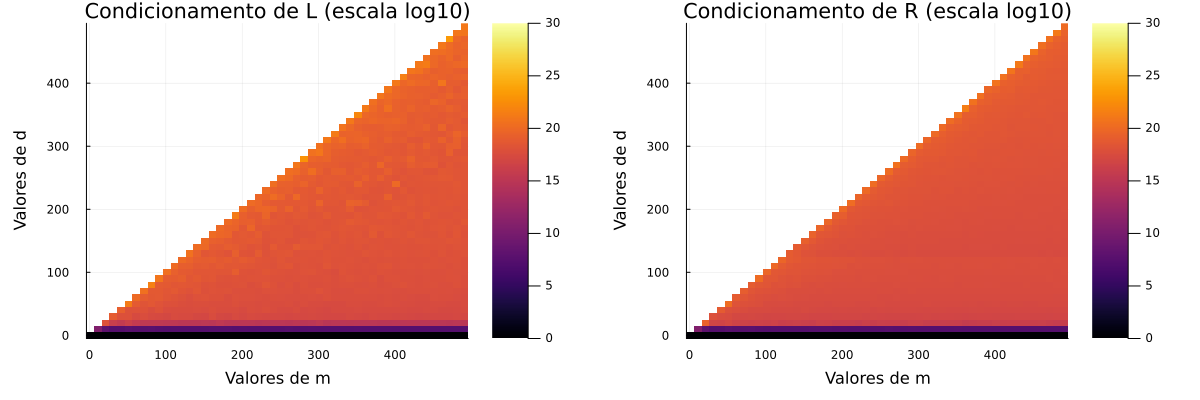

In [67]:
m = 500

condL = fill(NaN, m, m)
condR = fill(NaN, m, m)

for dim in 1:10:m
    for deg in 0:10:(dim - 1)
        X = rand(dim)
        L = [X[i]^j for i in 1:dim, j in 0:deg]
        try
            R = pinv(L)
            condL[dim, deg + 1] = cond(L)
            condR[dim, deg + 1] = cond(R)
        catch
            condL[dim, deg + 1] = Inf
            condR[dim, deg + 1] = Inf
        end
    end
end

dims = 1:10:m
degs = 0:10:(m-1)
condL_sub = condL[dims, degs .+ 1]
condR_sub = condR[dims, degs .+ 1]

degs_50 = 0:10:49
dims_d10 = 11:10:m

p1 = heatmap(collect(dims), collect(degs), log10.(condL_sub)',
    left_margin = 8Plots.mm, bottom_margin = 8Plots.mm,
    xlabel = "Valores de m",
    ylabel = "Valores de d", clim=(0, 30),
    title = "Condicionamento de L (escala log10)")

p2 = heatmap(collect(dims), collect(degs), log10.(condR_sub)',
    left_margin = 8Plots.mm, bottom_margin = 8Plots.mm,
    xlabel = "Valores de m",
    ylabel = "Valores de d", clim=(0, 30),
    title = "Condicionamento de R (escala log10)")
plot(p1, p2, layout = (1, 2), size = (1200, 400))

Para visualizar melhor o que acontece com o condicionamento de matrizes à medida em que $m$ e $d$ aumentam, fizemos o mesmo gráfico para $m$ até $50$. Também investigamos o condicionamento das matrizes para alguns valores arbitrários de $m$ e de $d$, conforme o outro valor varia

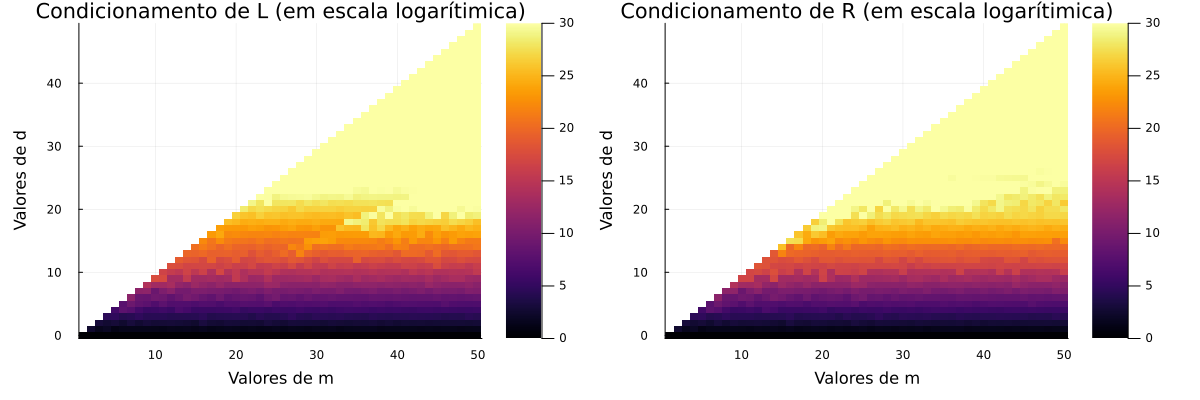

In [68]:
m = 50

condL = fill(NaN, m, m)
condR = fill(NaN, m, m)

for dim in 1:m
    for deg in 0:(dim - 1)
        X = rand(dim)*20 #adicionei esse termo para também aparecerem valores de X maiores que 1
        L = [X[i]^j for i in 1:dim, j in 0:deg]
        R = pinv(L)
        condL[dim, deg + 1] = cond(L)
        condR[dim, deg + 1] = cond(R)
    end
end

p1 = heatmap(1:m, 0:(m - 1), log10.(condL)', left_margin = 8Plots.mm, bottom_margin = 8Plots.mm,
    xlabel = "Valores de m",
    ylabel = "Valores de d", clim=(0, 30),
    title = "Condicionamento de L (em escala logarítimica)")
p2 = heatmap(1:m, 0:(m - 1), log10.(condR)',
    xlabel = "Valores de m",
    ylabel = "Valores de d", clim=(0, 30),
    title = "Condicionamento de R (em escala logarítimica)")

plot(p1, p2, layout = (1, 2), size = (1200, 400))

Percebemos, a partir dos gráficos, que conforme $m$ e $d$ aumentam o condicionamento de $L$ e de $R$ aumenta também! Em geral, esse condicionamento parece depender muito mais de $d$ do que de $m$: de fato,as cores parecem se manter essencialmente constantes em linhas horizontais!

## Item e)

A matriz de $L_X$ na base dos polinômios interpoladores de Lagrange será composta por colunas que são o resultado da aplicação da transformação  $L_X$ em cada vetor da base dos polinômios interpoladores de Lagrange. 

Como esses polinômios são definidos em $\mathcal{P}_d$ para um conjunto $X$ de $d+1$ elementos, e temos $m \geq d+1$, é necessário selecionar um subconjunto de $X$ sobre o qual definir os polinômios interpoladores de Lagrange. Assim, nesse subconjunto, $p_i(x_i) = \delta _{ij}$, e para $i>d+1$ o valor do polinômio está indefinido.

Com isso, a matriz $L$ terá formato $m \times d+1$ e será formada, a menos de troca de linhas, por um bloco de Identidade e um bloco gerado pelos polinômios interpoladores de Lagrange aplicados aos demais elementos de $X$! Notamos, inclusive, que esse bloco nunca terá 0s, porque um polinômio de grau até $d$ tem até $d$ raízes.

$L = \begin{bmatrix} 1 & 0 & ... & 0 \\ 0 & 1 & ... & 0 \\ ... &... & & ... \\ 0 & 0 & ... & 1 \\ ? & ? & ... & ?\\ ...&...&&... \end{bmatrix} := \begin{bmatrix} I_{d+1} \\ A \end{bmatrix}$

Se aplicada apenas ao espaço coluna de $L$,  $R$ poderia ser escrita simplesmente como $ \begin{bmatrix} I_{d+1} & 0 \end{bmatrix}$, afinal estaríamos procurando o único polinômio que se adequa aos $d+1$ primeiros pontos de $Lb. $

No entanto, é necessário encontrar uma matriz que possa ser aplicada a qualquer vetor $b$ em $R^m$. Poratanto, precisamos de uma solução de mínimos quadrados!
Multiplicando por blocos, encontramos a matriz $R$, dada por $(L^T L)^{-1}L^T$ igual a:

$(\begin{bmatrix} I_{d+1} & A^T \end{bmatrix} \begin{bmatrix} I_{d+1} \\ A \end{bmatrix})^{-1}\begin{bmatrix} I_{d+1} & A^T \end{bmatrix} = \begin{bmatrix} I_{d+1} + A^T A\end{bmatrix}^{-1}\begin{bmatrix} I_{d+1} & A^T \end{bmatrix} = \begin{bmatrix} (I_{d+1} + A^TA)^{-1} & (I_{d+1} + A^TA)^{-1}A^T \end{bmatrix}$


Para calcular uma matriz $L$ na base dos polinômios interpoladores de Lagrange, primeiramente temos que construir um conjunto $X$ de $m$ pontos e um vetor $b$ de valores associados a eles. Vamos fazer isso selecionando aleatoriamente. Como $X$ é gerado pela função rand, basta selecionar os d+1 primeiros elementos. 

Em seguida, vamos usar a função polyfit para obter os polinômios interpoladores de Lagrange, e vamos aplicar $L_X$ a cada um deles para obter a matriz $L$ - para economizar tempo e computação, poderíamos aplicar apenas aos últimos $m-d-1$ pontos de $X$, para obter apenas o bloco $A$!






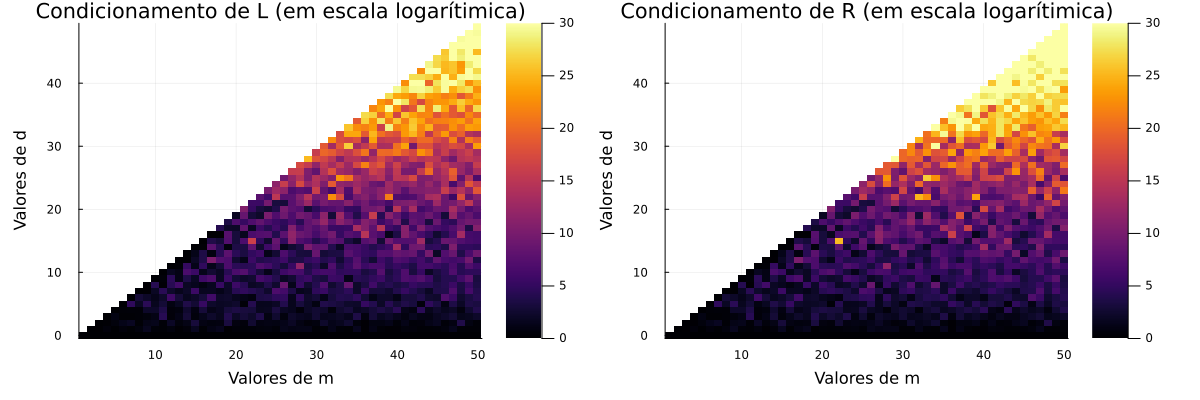

In [69]:
m = 50

condL = fill(NaN, m, m)
condR = fill(NaN, m, m)

for dim in 1:m
    for deg in 0:(dim - 1)
        X = rand(dim)
        subsetx = first(X, deg + 1)
        y = zeros(deg + 1)

        poly = []

        for i in 1:(deg + 1)
            y[i] = 1
            push!(poly, fit(subsetx, y, deg))
            y[i] = 0
        end

        L = hcat([p.(X) for p in poly]...)
        R = pinv(L)
        condL[dim, deg + 1] = cond(L)
        condR[dim, deg + 1] = cond(R)
    end
end

p1 = heatmap(1:m, 0:(m - 1), log10.(condL)', left_margin = 8Plots.mm, bottom_margin = 8Plots.mm,
    xlabel = "Valores de m",
    ylabel = "Valores de d", clim=(0, 30),
    title = "Condicionamento de L (em escala logarítimica)")
p2 = heatmap(1:m, 0:(m - 1), log10.(condR)',
    xlabel = "Valores de m",
    ylabel = "Valores de d", clim=(0, 30),
    title = "Condicionamento de R (em escala logarítimica)")

plot(p1, p2, layout = (1, 2), size = (1200, 400))

Nos gráficos, vemos uma relação parecida com a do item anterior na qual o condicionamento aumenta conforme os valores de d aumentam. No entanto, levantamos uma bandeira vermelha ao perceber que o condicionamento não dava 0 na diagonal $m=d+1$. Afinal, para esses valores a matriz $L$ é simplesmente a Identidade! Resolvemos, então, escrever nossa própria função ao invés de utilizar a fit da Polynomials, e obtivemos um resultado mais condizente com o esperado!

In [70]:
function lagrange(X, i)
    return x -> begin
        val = 1.0
        for j in 1:length(X)
            if j != i
                val *= (x - X[j]) / (X[i] - X[j])
            end
        end
        return val
    end
end

lagrange (generic function with 1 method)

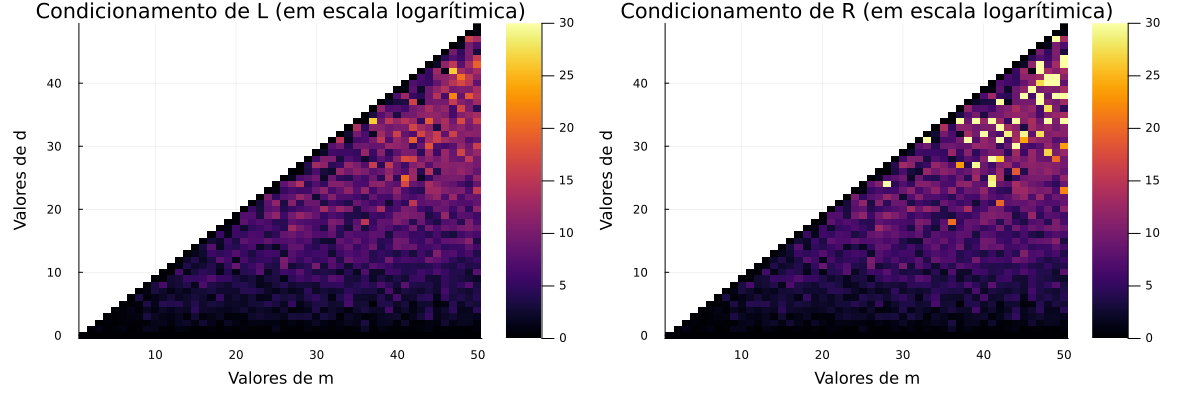

In [71]:
m = 50

condL = fill(NaN, m, m)
condR = fill(NaN, m, m)

for dim in 1:m
    for deg in 0:(dim - 1)
        X = rand(dim)
        subsetx = first(X, deg + 1)

        poly = []

        for i in 1:(deg + 1)
            push!(poly, lagrange(subsetx, i))
        end

        L = hcat([p.(X) for p in poly]...)
        R = pinv(L)
        condL[dim, deg + 1] = cond(L)
        condR[dim, deg + 1] = cond(R)
    end
end

p1 = heatmap(1:m, 0:(m - 1), log10.(condL)', left_margin = 8Plots.mm, bottom_margin = 8Plots.mm,
    xlabel = "Valores de m",
    ylabel = "Valores de d", clim=(0, 30),
    title = "Condicionamento de L (em escala logarítimica)")
p2 = heatmap(1:m, 0:(m - 1), log10.(condR)',
    xlabel = "Valores de m",
    ylabel = "Valores de d", clim=(0, 30),
    title = "Condicionamento de R (em escala logarítimica)")

plot(p1, p2, layout = (1, 2), size = (1200, 400))

No gráfico, percebemos um certo "ruído", mas apesar disso as relações se mantém razoavelmente claras: o condicionamento depende quase exclusivamente de $d$ e, conforme esperado, é perfeitamente 0 na diagonal m=d+1. Além disso, notamos que ao calcular lagrange diretamente, obtivemos valores de condicionamento razoavelmente menores!


Por falta de clareza acerca da complexidade computacional da implementação da `pinv` em julia e também por saber que ela ignora valores singulares muito pequenos, resolvemos também calcular a R "na mão" e comparar!

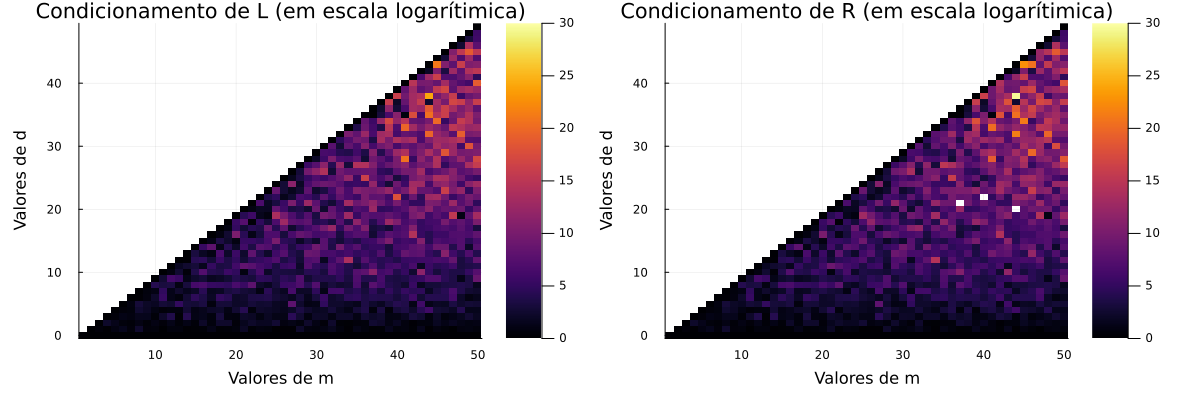

In [72]:
m = 50

condL = fill(NaN, m, m)
condR = fill(NaN, m, m)

for dim in 1:m
    for deg in 0:(dim - 1)
        X = rand(dim)
        subsetx = first(X, deg + 1)

        poly = []

        for i in 1:(deg + 1)
            push!(poly, lagrange(subsetx, i))
        end

        L = hcat([p.(X) for p in poly]...)
        try
            R = inv(L'*L)*L'
            condL[dim, deg + 1] = cond(L)
            condR[dim, deg + 1] = cond(R)
        catch
            condL[dim, deg + 1] = cond(L)
            condR[dim, deg + 1] = Inf
        end
    end
end

p1 = heatmap(1:m, 0:(m - 1), log10.(condL)', left_margin = 8Plots.mm, bottom_margin = 8Plots.mm,
    xlabel = "Valores de m",
    ylabel = "Valores de d", clim=(0, 30),
    title = "Condicionamento de L (em escala logarítimica)")
p2 = heatmap(1:m, 0:(m - 1), log10.(condR)',
    xlabel = "Valores de m",
    ylabel = "Valores de d", clim=(0, 30),
    title = "Condicionamento de R (em escala logarítimica)")

plot(p1, p2, layout = (1, 2), size = (1200, 400))

Vemos que, ao calcular a inversa manualmente, temos alguns problemas de matrizes singulares (ou tão perto disso quanto necessário para que a LinearAlgebra.inv não rode) e também percebemos valores de condicionamento praticamente iguais aos da tentativa anterior!

Novamente, vemos que o condicionamento cresce conforme $d$ cresce.

## Item f)

*Na base canônica:*
A construção da matriz $L_X$ usa dois loops aninhados que aplicam a cada um dos $m$ elementos de $X$ as potências de $0$ a $d$. Isso tem um custo computacional $O(md)$.

*Na base de Lagrange:*
A construção da matriz $L_X$ 
A construção da matriz $R_{X, d}$ se dá pelo cálculo da pseudoinversa de $L_X$, a função utilizada para isso calcula via Decomposição em Valores Singulares (SVD), a decomposição em si tem custo $O(md^2)$ já a inversão dos valores singulares e as multiplicações custo $O(d^3)$, resultando no custo computacional $O(md^2)$.

Em ambos os casos, a construção da matriz $R_{X, d}$ se dá pelo cálculo da pseudoinversa de $L_X$. A função .pinv do Julia faz essas contas via Decomposição em Valores Singulares (SVD). A decomposição tem custo $O(md^2)$, e a inversão dos valores singulares e as multiplicações têm custo $O(d^3)$. Como $d<m$, temos um custo computacional $O(md^2)$.

Já calculando a pseudoinversa na mão, temos que calcular $L^TL$, com custo $~O(md^2)$, inverter a matriz resultante, custo $~O(d^3)$, e multiplicar essa matriz por $L^T$, com custo $~O(md^2)$. Como $m>d$, temos um custo final $~O(md^2)$.

Nesse sentido, percebemos que existe um trade-off entre condicionamento e complexidade computacional: para obter uma matriz mais "bem comportada", são necessários mais cálculos e melhor poder computacional. E, nos casos grandes, onde o condicionamento fica cada vez mais relevante, a diferença no custo computacional também fica mais expressiva!

## Questão 3. Interpolação e Extrapolação.

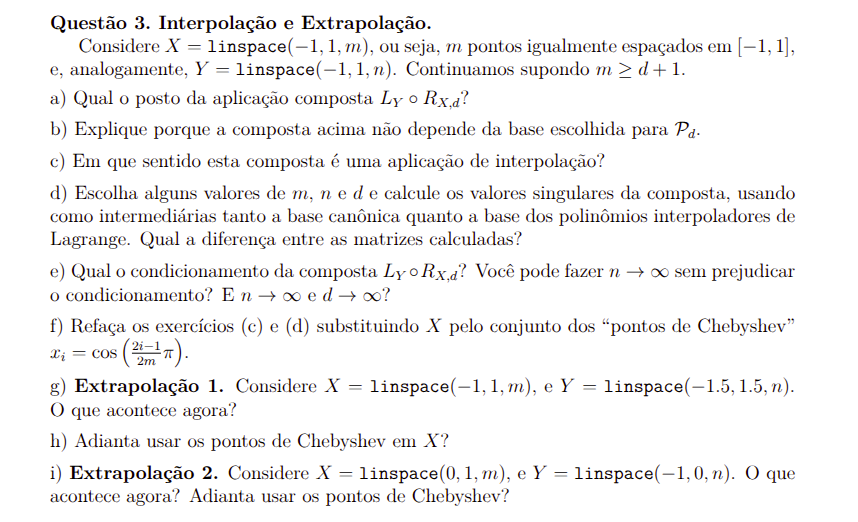

## Item a)

Sabemos que, se $A$ tem inversa à direita (posto cheio nas linhas), então o posto de $BA$ será o posto de $B$. Afinal, o núcleo à esquerda de $BA$ será exatamente o núcleo à esquerda de $B$, pois 

$x^TBA = 0 \iff x^TBAA^{-1} = 0 \iff x^TB = 0$!

E, como $BA$ tem o mesmo número de linhas que B, o posto dessas matrizes deve ser o mesmo!

Do item anterior, sabemos que $R_{X, d}$ tem inversa à direita: a transformação $L_X$. Logo, o posto de $L_Y \circ R_{X, d}$ é o posto de $L_Y$ e, como esta tem posto cheio e dimensão $n \times d+1$, o posto da composta será $min(n, d+1)$

## Item b)

O polinômio p resultante da transformação $R_{X,d}$ será o mesmo, independentemente da base de $P_d$ escolhida para representá-lo, então o valor de $p(y_i)$ será sempre o mesmo, independente da base de $P_d$. Como a composta receve um vetor de $R^m$ e retorna um vetor de $R^n$, ela não precisa "se preocupar com" em que base os polinômios estão sendo representados, porque não vai alterar a interpretação dos valores recebidos nem o valor do resultado fornecido!

## Item c)

A composta $L_Y \circ R_{X, d}$ é uma aplicação de interpolação porque recebe um conjunto de valores associados a pontos $x_i$ no intervalo $[-1, 1]$ e busca a função polinomial que melhor se ajusta a eles, para depois aplicá-la a um outro conjunto de pontos $y_j$ compreendidos nesse mesmo intervalo.

Essencialmente, $L_Y \circ R_{X, d}$ é uma maneira de "prever" valores de pontos desconhecidos dentro de um intervalo de pontos conhecidos!



## Item d)

In [73]:
using Random

canon_values = []
lagrange_values = []

for n in 2:50
    Y = range(-1, 1, length=n)
    cvals = []
    lvals = []
    for m in 2:50
        X = range(-1, 1, length=m)
        for d in 0:(m-1)
            subsetx = X[randperm(m)[1:(d+1)]]
            y = zeros(d + 1)
            poly = []
            
            for i in 1:(d+1)
                y[i] = 1
                push!(poly, fit(subsetx, y, d))
                y[i] = 0
            end

            L_X = hcat([p.(X) for p in poly]...)
            R = pinv(L_X)
            L = hcat([p.(Y) for p in poly]...)
            
            LR = L * R

            L_X_c = hcat([(X).^deg for deg in 0:d]...)
            R_c = pinv(L)
            L_c = hcat([(Y).^deg for deg in 0:d]...)
            LR_C = L_c * R_c
            
            push!(cvals, svdvals(LR_C))
            push!(lvals, svdvals(LR))
        end
    end
    push!(canon_values, cvals)
    push!(lagrange_values, lvals)
end


e) Qual o condicionamento da composta LY ◦RX,d? Você pode fazer n →∞sem prejudicar
o condicionamento? E n →∞ e d →∞?
## Item e)

A princípio, vamos testar com alguns valores de $n$, variando $m$ e $d$, para termos uma ideia do comportamento da composta.

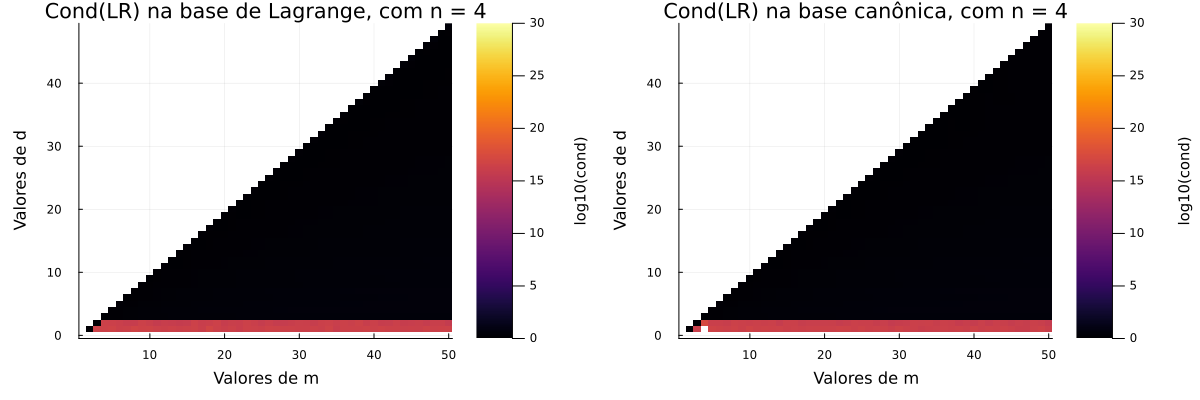

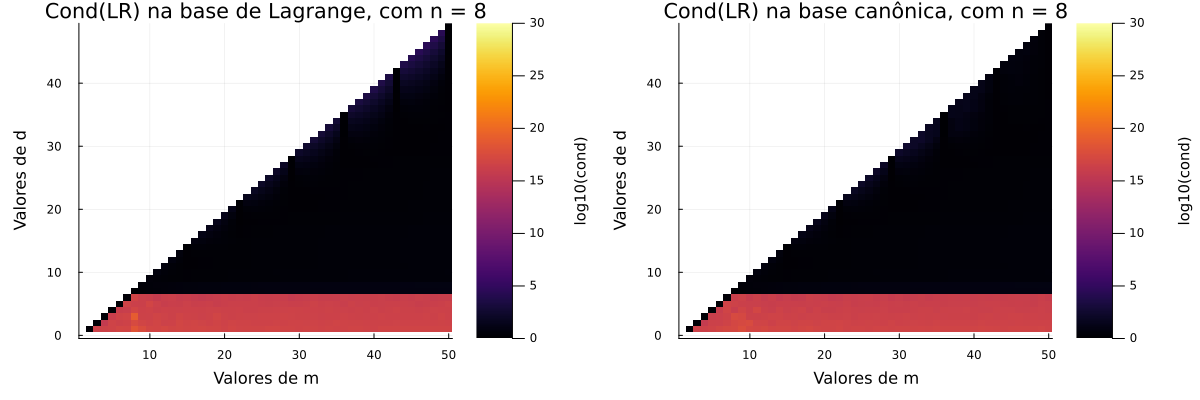

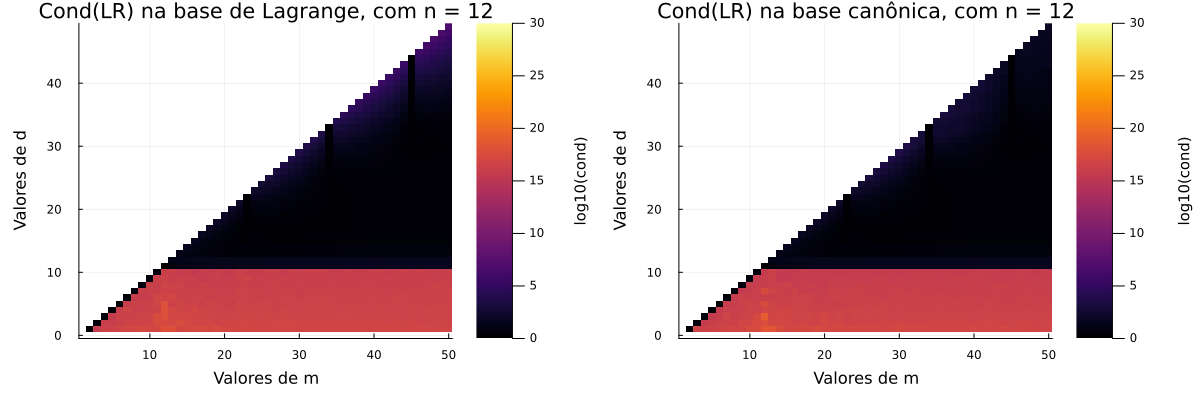

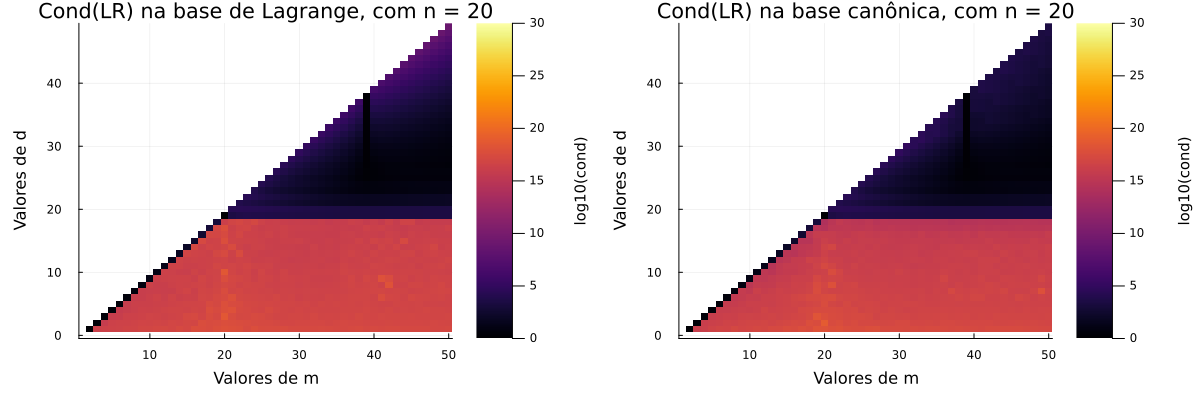

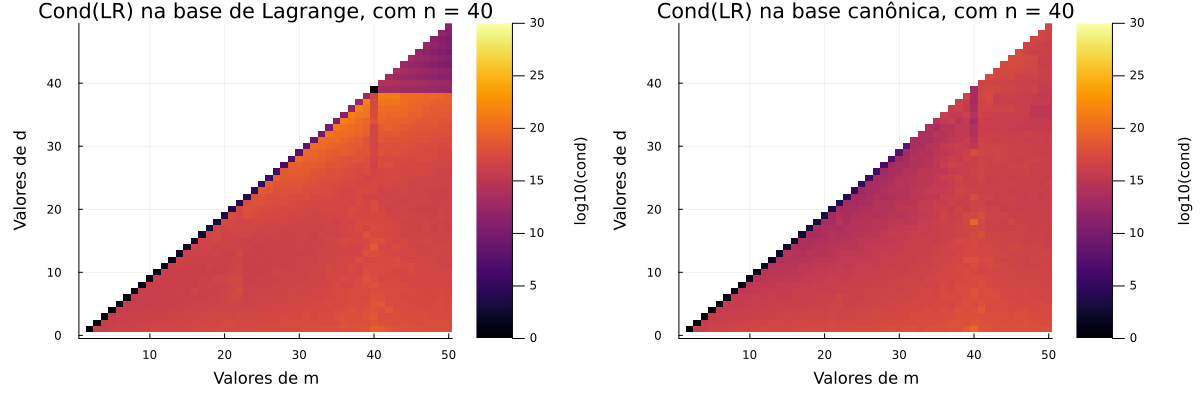

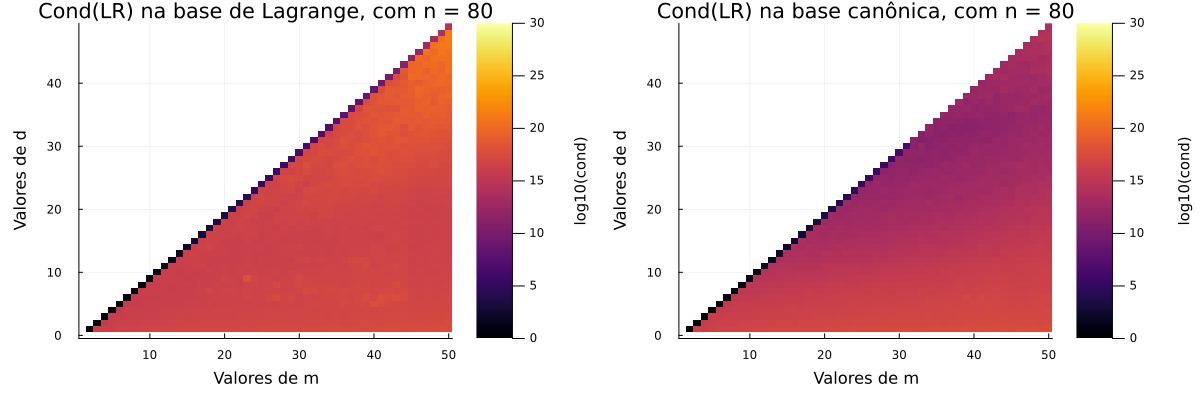

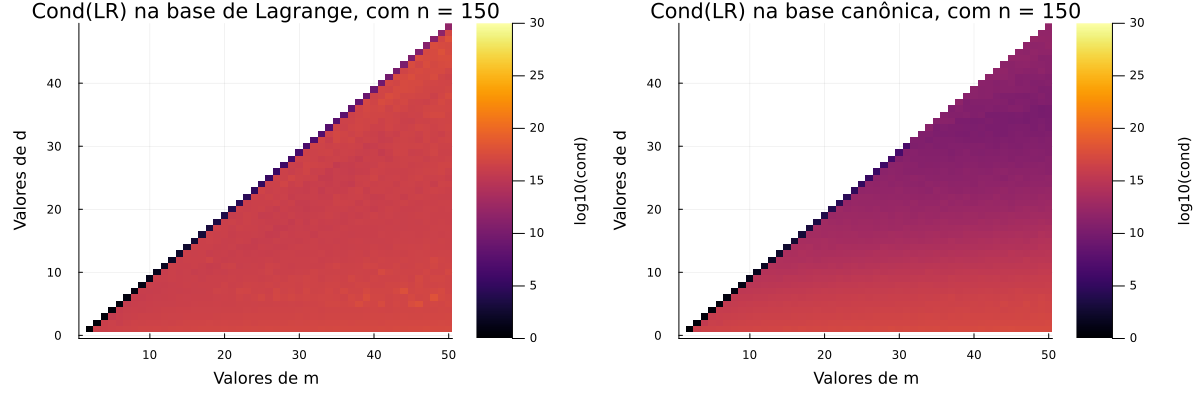

In [77]:
m_max = 50
n_values = [ 4, 8, 12, 20, 40, 80, 150]

for n in n_values
    condLR_l = fill(NaN, m_max, m_max)
    condLR_c = fill(NaN, m_max, m_max)

    Y = range(-1, 1, n)
    for m in 2:m_max
        X = range(-1, 1, m)
        for d in 1:(m - 1)
            idxs = round.(Int, range(1, m, length=(d+1)))
            subsetx = X[idxs]
            poly = []
            
            for i in 1:(d+1)
                push!(poly, lagrange(subsetx, i))
            end

            L_X = hcat([p.(X) for p in poly]...)
            R = pinv(L_X)
            L = hcat([p.(Y) for p in poly]...)
            LR = L * R

            L_X_c = hcat([(X).^d for d in 0:d]...)
            R_c = pinv(L_X_c)
            L_c = hcat([(Y).^d for d in 0:d]...)
            LR_c = L_c * R_c

            condLR_l[m, d + 1] = cond(LR)
            condLR_c[m, d + 1] = cond(LR_c)
        end
    end

    p1 = heatmap(1:m_max, 0:(m_max - 1), log10.(condLR_l)', left_margin = 8Plots.mm, bottom_margin = 8Plots.mm, right_margin = 8Plots.mm,
        xlabel = "Valores de m",
        colorbar_title = "log10(cond)",
        ylabel = "Valores de d", clim=(0, 30),
        title = "Cond(LR) na base de Lagrange, com n = $n")
    p2 = heatmap(1:m_max, 0:(m_max - 1), log10.(condLR_c)',
        xlabel = "Valores de m",
        colorbar_title = "log10(cond)\n",
        ylabel = "Valores de d", clim=(0, 30),
        title = "Cond(LR) na base canônica, com n = $n")

    display(plot(p1, p2, layout = (1, 2), size = (1200, 400)))
end

A partir dos gráficos, percebemos algo curioso: a partir do momento em que d+1 fica maior que n, o condicionamento da composta muda completamente! Isso faz todo o sentido, porque o formato da matriz $L_Y$ muda (de "alta e magra" para "baixa e gorda") e o posto dela muda também, mudando consequentemente o posto da composta $L_Y \circ R_{X, d}$

Além disso, temos "linhas" verticais em que o condicionamento da composta muda. Essas linhas aparecem em $m=n$ para $d+1<n$, com pontos de condicionamento maior do que a vizinhança, especialmente com $d+1$ próximo de $n$. Também temos linhas em pontos que aparentam ser $m = k(n-1)+1$, com $k$ inteiro: para $d+1>n$, o condicionamento da composta é muito próximo de $1$. 

Por fim, em $m=n=d+1$, temos $L_Y \circ R_{X, d} = I$ e o condicionamento igual a 1

Para analisar o impacto da escolha dos pontos, então refaremos os gráficos com escolha aleatória.

In [75]:
using Random

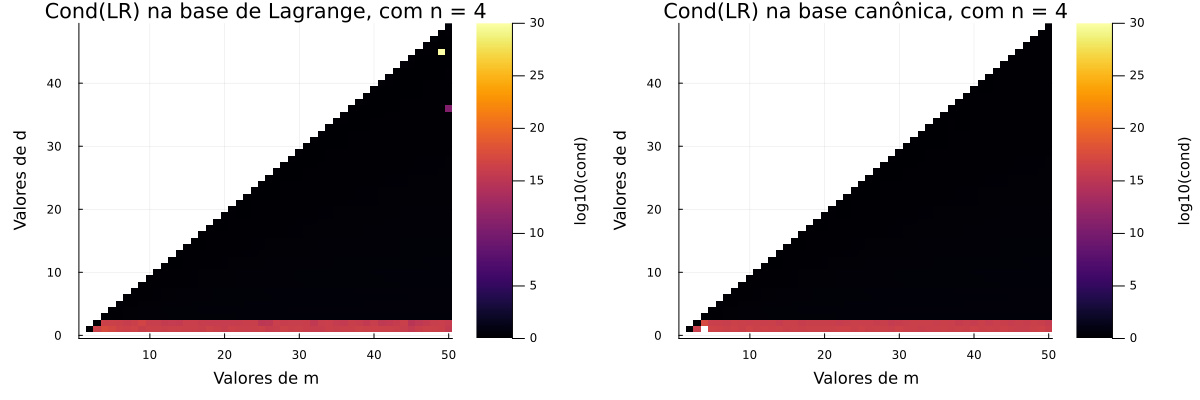

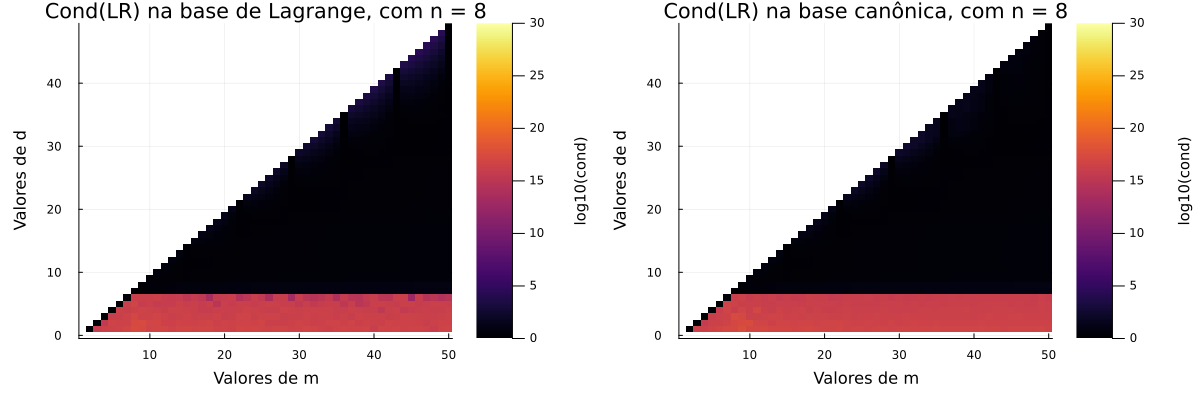

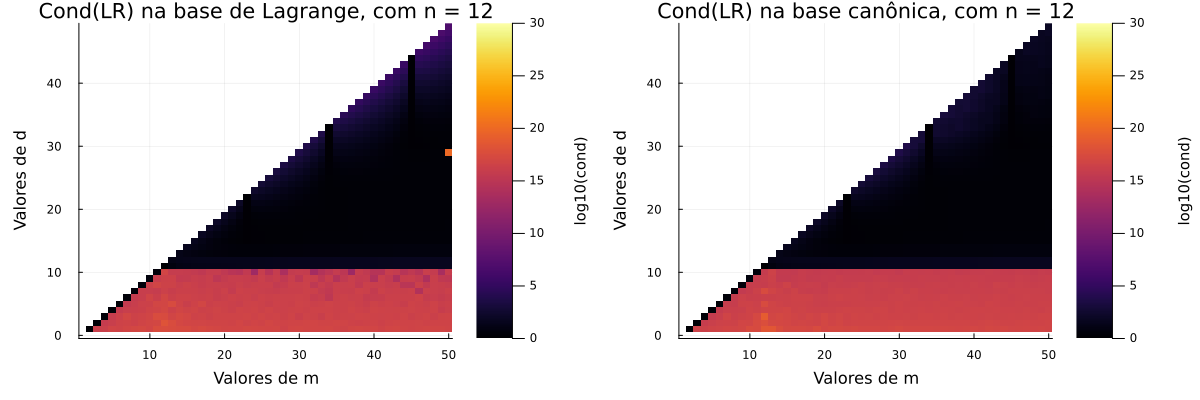

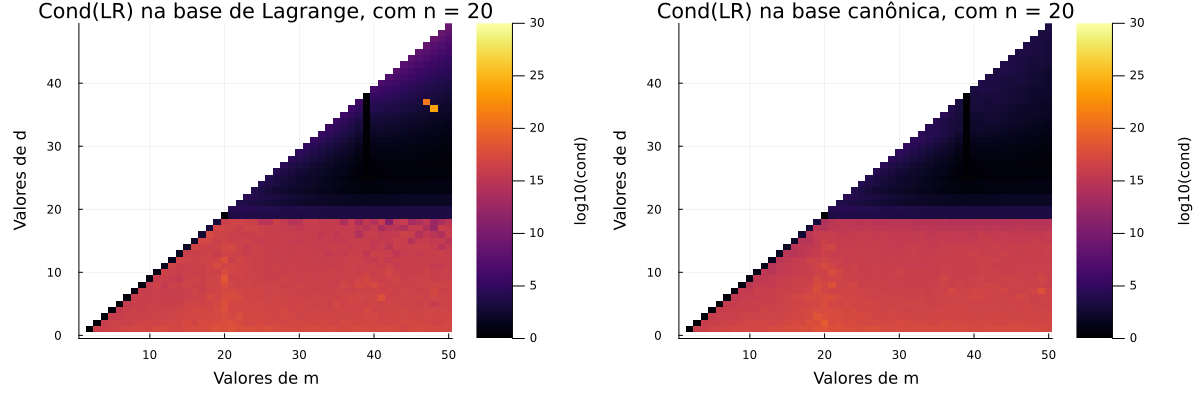

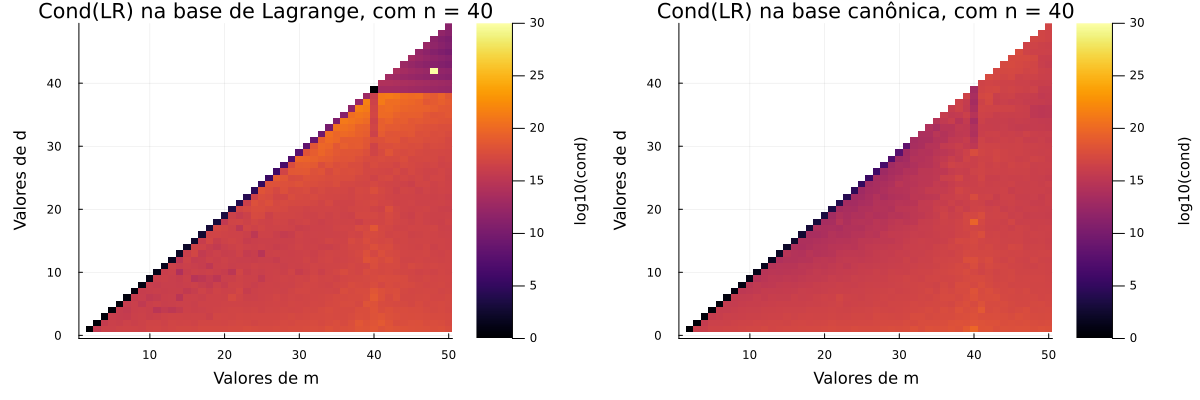

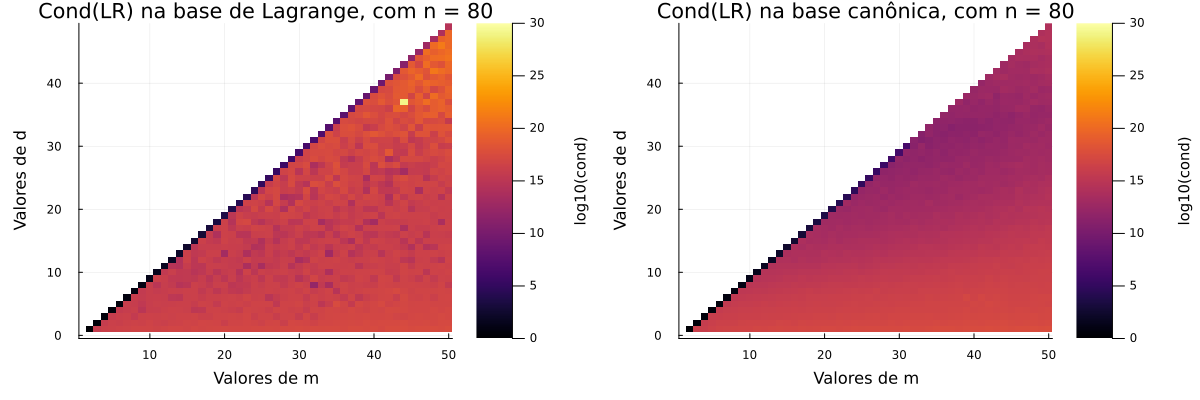

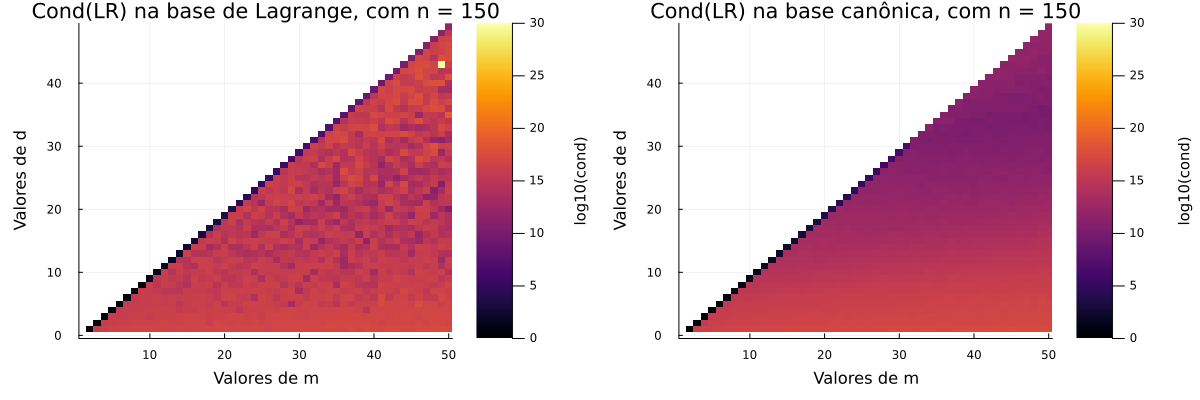

In [ ]:
m_max = 50
n_values = [ 4, 8, 12, 20, 40, 80, 150]

for n in n_values
    condLR_l = fill(NaN, m_max, m_max)
    condLR_c = fill(NaN, m_max, m_max)

    Y = range(-1, 1, n)
    for m in 2:m_max
        X = range(-1, 1, m)
        for d in 1:(m - 1)
            subsetx = shuffle(X)[1:d+1]
            poly = []
            
            for i in 1:(d+1)
                push!(poly, lagrange(subsetx, i))
            end

            L_X = hcat([p.(X) for p in poly]...)
            R = pinv(L_X)
            L = hcat([p.(Y) for p in poly]...)
            LR = L * R

            L_X_c = hcat([(X).^d for d in 0:d]...)
            R_c = pinv(L_X_c)
            L_c = hcat([(Y).^d for d in 0:d]...)
            LR_c = L_c * R_c

            condLR_l[m, d + 1] = cond(LR)
            condLR_c[m, d + 1] = cond(LR_c)
        end
    end

    p1 = heatmap(1:m_max, 0:(m_max - 1), log10.(condLR_l)', left_margin = 8Plots.mm, bottom_margin = 8Plots.mm, right_margin = 8Plots.mm,
        xlabel = "Valores de m",
        colorbar_title = "log10(cond)",
        ylabel = "Valores de d", clim=(0, 30),
        title = "Cond(LR) na base de Lagrange, com n = $n")
    p2 = heatmap(1:m_max, 0:(m_max - 1), log10.(condLR_c)',
        xlabel = "Valores de m",
        colorbar_title = "log10(cond)\n",
        ylabel = "Valores de d", clim=(0, 30),
        title = "Cond(LR) na base canônica, com n = $n")

    display(plot(p1, p2, layout = (1, 2), size = (1200, 400)))
end

Vimos que as características se repetem, indicando que escolher aleatoriamente ou escolher pontos igualmente espaçados tem pouca influência no condicionamento das matrizes.

Em geral, vemos que os valores do condicionamento parecem se manter constantes conforme $m$ varia, indicando que podemos fazer $m \rightarrow \infty$ sem prejuízo ao condicionamento. 

Refaremos os gráficos, então, fixando valores de $m$ e analisando o comportamento de $n$ e de $d$

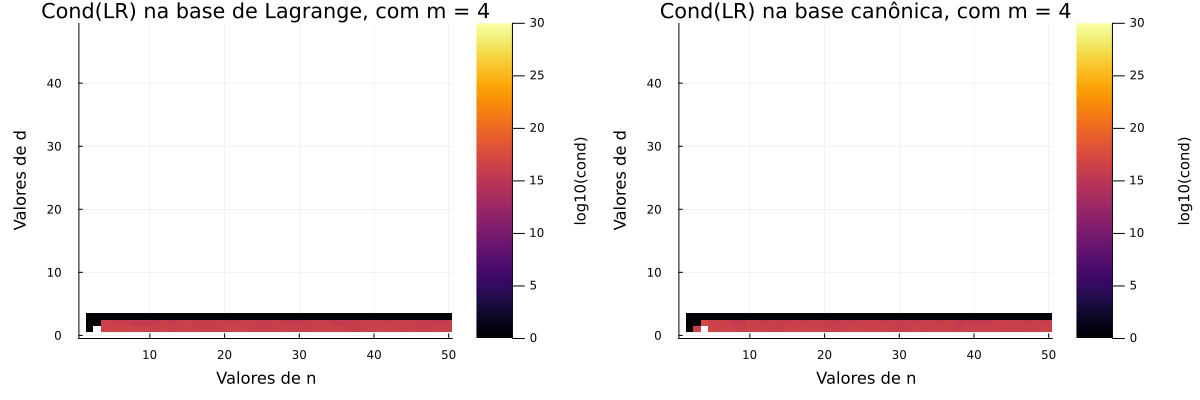

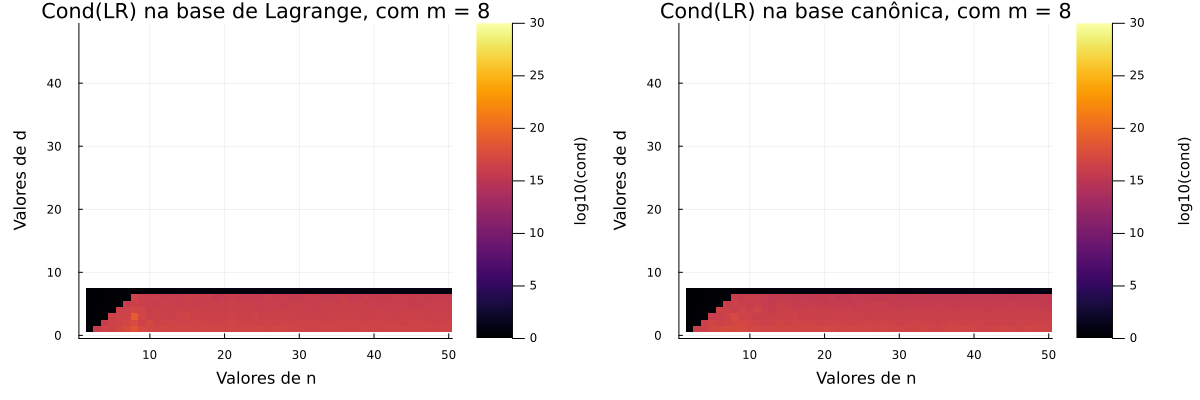

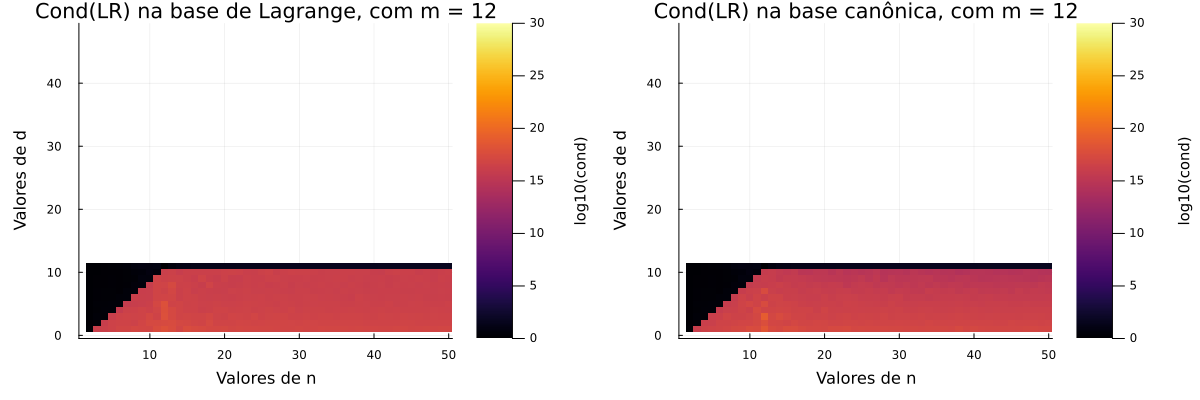

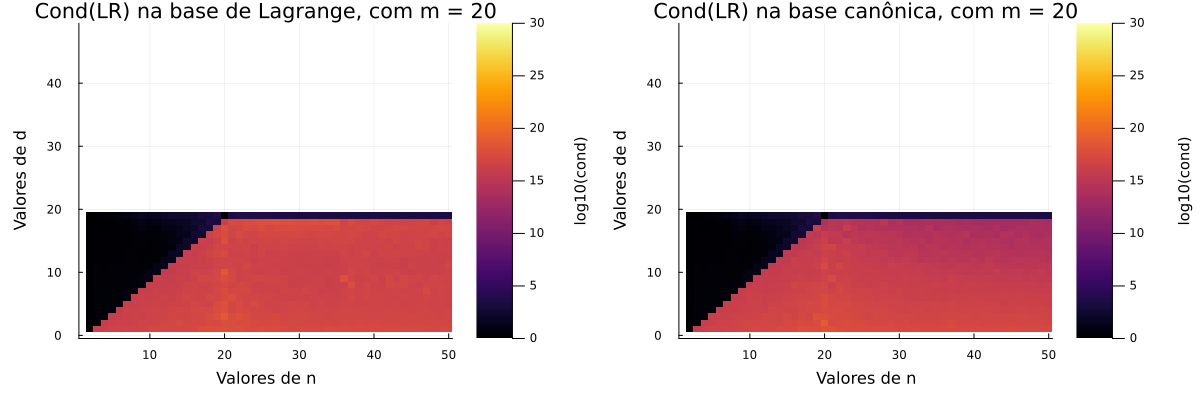

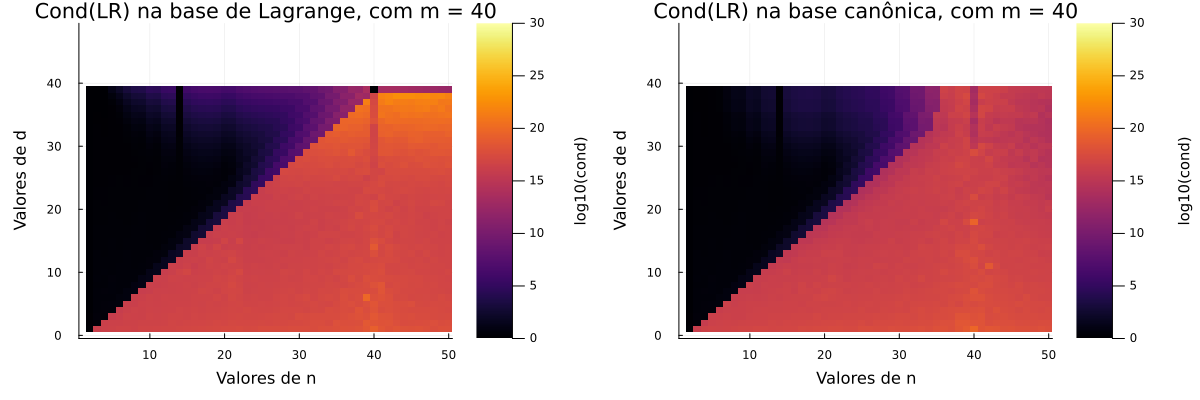

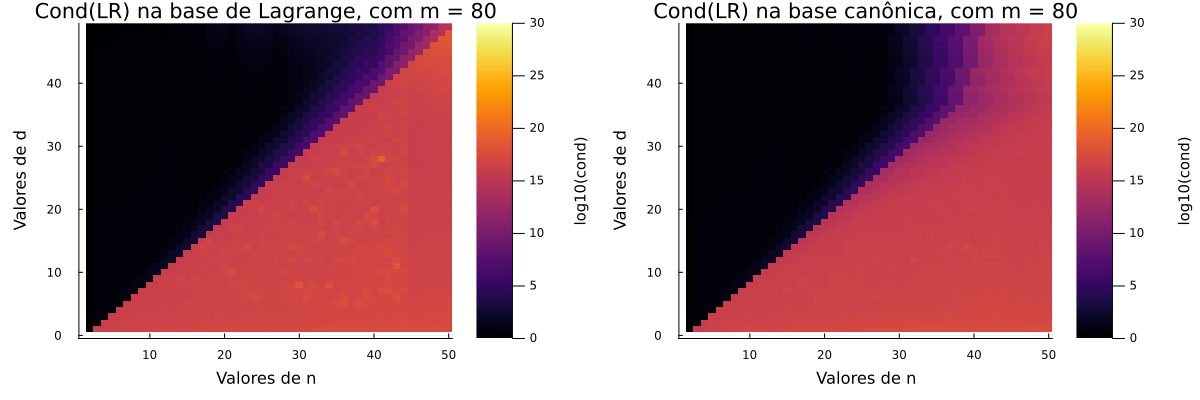

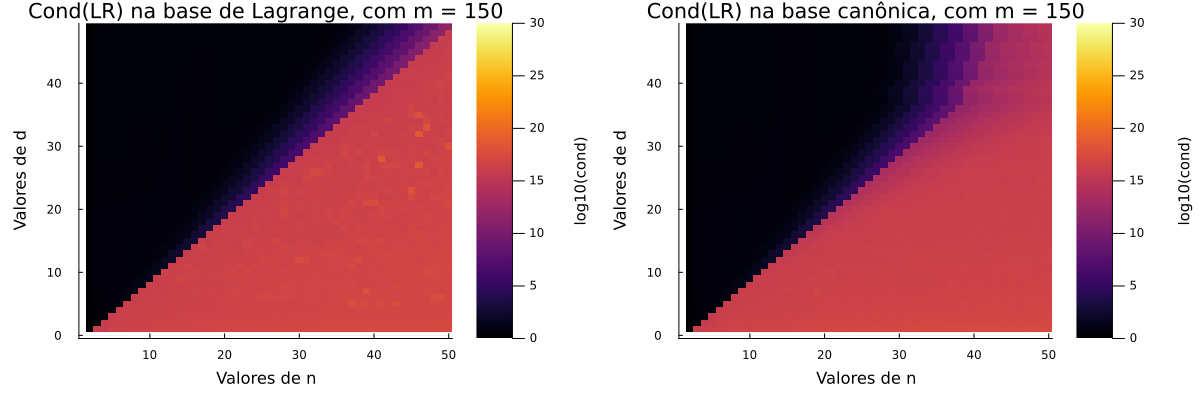

In [82]:
m_max = 50
n_values = [ 4, 8, 12, 20, 40, 80, 150]

for m in n_values
    condLR_l = fill(NaN, m_max, m_max)
    condLR_c = fill(NaN, m_max, m_max)

    X = range(-1, 1, m)
    for n in 2:m_max
        Y = range(-1, 1, n)
        for d in 1:min(m - 1, m_max - 1)
            idxs = round.(Int, range(1, m, length=(d+1)))
            subsetx = X[idxs]
            poly = []
            
            for i in 1:(d+1)
                push!(poly, lagrange(subsetx, i))
            end

            L_X = hcat([p.(X) for p in poly]...)
            R = pinv(L_X)
            L = hcat([p.(Y) for p in poly]...)
            LR = L * R

            L_X_c = hcat([(X).^d for d in 0:d]...)
            R_c = pinv(L_X_c)
            L_c = hcat([(Y).^d for d in 0:d]...)
            LR_c = L_c * R_c

            condLR_l[n, d + 1] = cond(LR)
            condLR_c[n, d + 1] = cond(LR_c)
        end
    end

    p1 = heatmap(1:m_max, 0:(m_max - 1), log10.(condLR_l)', left_margin = 8Plots.mm, bottom_margin = 8Plots.mm, right_margin = 8Plots.mm,
        xlabel = "Valores de n",
        colorbar_title = "log10(cond)",
        ylabel = "Valores de d", clim=(0, 30),
        title = "Cond(LR) na base de Lagrange, com m = $m")
    p2 = heatmap(1:m_max, 0:(m_max - 1), log10.(condLR_c)',
        xlabel = "Valores de n",
        colorbar_title = "log10(cond)\n",
        ylabel = "Valores de d", clim=(0, 30),
        title = "Cond(LR) na base canônica, com m = $m")

    display(plot(p1, p2, layout = (1, 2), size = (1200, 400)))
end

Analisando os gráficos, vemos que para valores grandes de $m$ o condicionamento na base de Lagrange acaba explodindo em alguns pontos! No entanto, como o condicionamento na base canônica permanece bem comportado, supomos que esse comportamento se deva a erros de cálculo.

Nesse caso, vemos que o maior impacto no condicionamento é se $n$ é maior que $d+1$ ou não!

Assim, vemos que $n \rightarrow \infty$ é um problema se $n > d+1$, porque o condicionamento explode! Porém $m \rightarrow \infty$ e $d \rightarrow \infty$ parecem ser feitos sem grandes prejuízos ao condicionamento, contanto que $n \leq d + 1$

f) Refaça os exercícios (d) e (e) substituindo X pelo conjunto dos “pontos de Chebyshev”
xi = cos (2i−1 2m π)


g) Extrapolação 1. Considere X = linspace(−1,1,m), e Y = linspace(−1.5,1.5,n).
O que acontece agora?


h) Adianta usar os pontos de Chebyshev em X?


i) Extrapolação 2. Considere X = linspace(0,1,m), e Y = linspace(−1,0,n). O que
acontece agora? Adianta usar os pontos de Chebyshev?